# Gas Sensor Array Drift Classification

Multiclass gas classification using Logistic Regression implemented from scratch with NumPy on the UCI Gas Sensor Array Drift Dataset.

The model is evaluated under both random and temporal batch-based splits to investigate performance changes over time.

## 1. Dataset Overview

The **UCI Gas Sensor Array Drift Dataset** contains measurements collected from a 16-sensor gas detection system over multiple batches.

| Property | Value |
|---|---:|
| Samples | 13,910 |
| Features | 128 |
| Gas classes | 6 |
| Sensor elements | 16 |
| Batches | 10 |

The raw data is provided in LIBSVM-like .dat files, where each row contains a class label followed by 128 `index:value` feature pairs.

The batch identifier is preserved during loading because it is later used for temporal evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Class Labels

The target labels are encoded as integers from 1 to 6:

1. Ethanol
2. Ethylene
3. Ammonia
4. Acetaldehyde
5. Acetone
6. Toluene

The numerical labels are used for modeling and mapped to gas names for interpretation.

In [2]:
class_names = {
    1: "1-Ethanol",
    2: "2-Ethylene",
    3: "3-Ammonia",
    4: "4-Acetaldehyde",
    5: "5-Acetone",
    6: "6-Toluene"
}

## 2. Data Loading & Validation

This section builds a custom parser for the `.dat` files, combines all 10 batches into a single dataset, and validates the result before any modeling begins.

In [3]:
def parse_batch(file_path, batch_number):
    y = []
    X = []
    batch_id = []
    with open(file_path, "r") as file:
        for line in file:
            parts = line.split()

            y.append(int(parts[0]))

            features = [float(feature.split(":")[1]) for feature in parts[1:]]

            X.append(features)
            batch_id.append(batch_number)
    return np.array(X), np.array(y), np.array(batch_id)

In [4]:
X_all = []
y_all = []
batch_all = []

for batch_number in range(1, 11):
    file_path = f"../data/raw/batch{batch_number}.dat"

    X_batch, y_batch, batch_id = parse_batch(file_path, batch_number)

    X_all.append(X_batch)
    y_all.append(y_batch)
    batch_all.append(batch_id)

In [5]:
X = np.vstack(X_all)
y = np.concatenate(y_all)
batch_id = np.concatenate(batch_all)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("batch_id shape:", batch_id.shape)

print("Number of samples:", len(X))
print("Number of features:", X.shape[1])

print("Unique classes:", np.unique(y))
print("Unique batches:", np.unique(batch_id))

X shape: (13910, 128)
y shape: (13910,)
batch_id shape: (13910,)
Number of samples: 13910
Number of features: 128
Unique classes: [1 2 3 4 5 6]
Unique batches: [ 1  2  3  4  5  6  7  8  9 10]


### Data Quality Check

Basic data-quality checks are performed before modeling, including missing values, infinite values, and feature statistics.

In [6]:
missing_values = np.isnan(X).sum()
infinite_values = np.isinf(X).sum()

print("Total missing values:", missing_values)
print("Total infinite values:", infinite_values)

print("X dtype:", X.dtype)
print("y dtype:", y.dtype)
print("batch_id dtype:", batch_id.dtype)

print("Minimum value:", X.min())
print("Maximum value:", X.max())
print("Mean value:", X.mean())
print("Standard deviation:", X.std())

Total missing values: 0
Total infinite values: 0
X dtype: float64
y dtype: int64
batch_id dtype: int64
Minimum value: -23660.6348
Maximum value: 670687.3477
Mean value: 2791.463331668445
Standard deviation: 14413.86696748561


In [7]:
feature_std = X.std(axis=0)

print("Minimum feature std:", feature_std.min())
print("Maximum feature std:", feature_std.max())

Minimum feature std: 0.5286414698010402
Maximum feature std: 69842.27531023844


## 3. Exploratory Data Analysis

We examine class and batch distributions to understand the structure of the dataset before modeling.

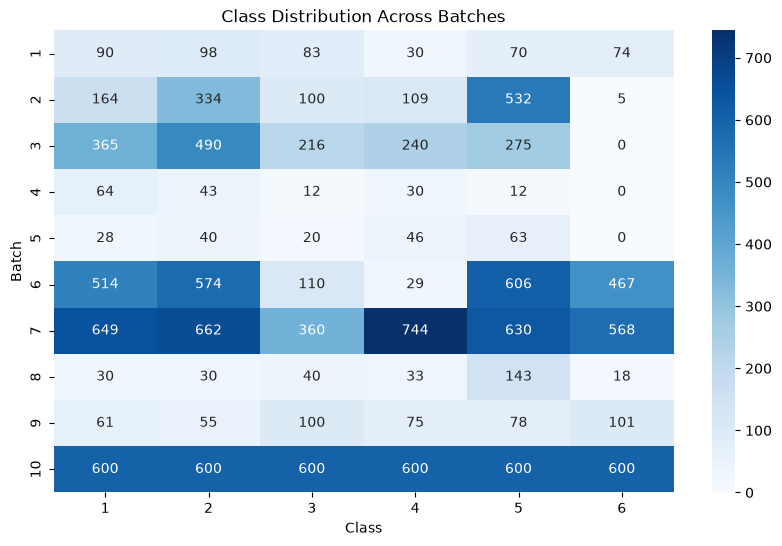

In [8]:

class_batch_counts = pd.crosstab(batch_id, y)

plt.figure(figsize=(10, 6))
sns.heatmap(
    class_batch_counts,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Class Distribution Across Batches")
plt.xlabel("Class")
plt.ylabel("Batch")

plt.show()

In [9]:
batch_counts = pd.Series(batch_id).value_counts().sort_index()
print(batch_counts)

1      445
2     1244
3     1586
4      161
5      197
6     2300
7     3613
8      294
9      470
10    3600
Name: count, dtype: int64


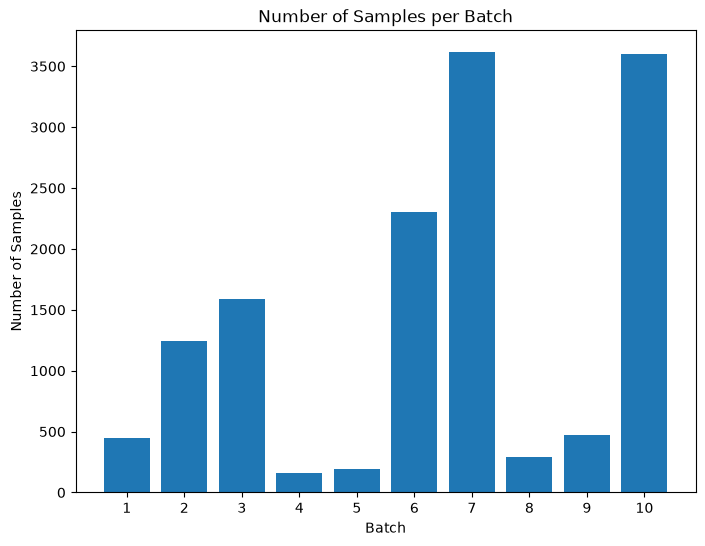

In [10]:
plt.figure(figsize=(8, 6))
plt.bar(batch_counts.index, batch_counts.values)
plt.title("Number of Samples per Batch")
plt.xlabel("Batch")
plt.ylabel("Number of Samples")

plt.xticks(batch_counts.index)
plt.show()

### Sample Distribution Across Batches

The number of samples varies substantially across batches.

In [11]:
class_counts = pd.Series(y).value_counts().sort_index()
print(class_counts)

1    2565
2    2926
3    1641
4    1936
5    3009
6    1833
Name: count, dtype: int64


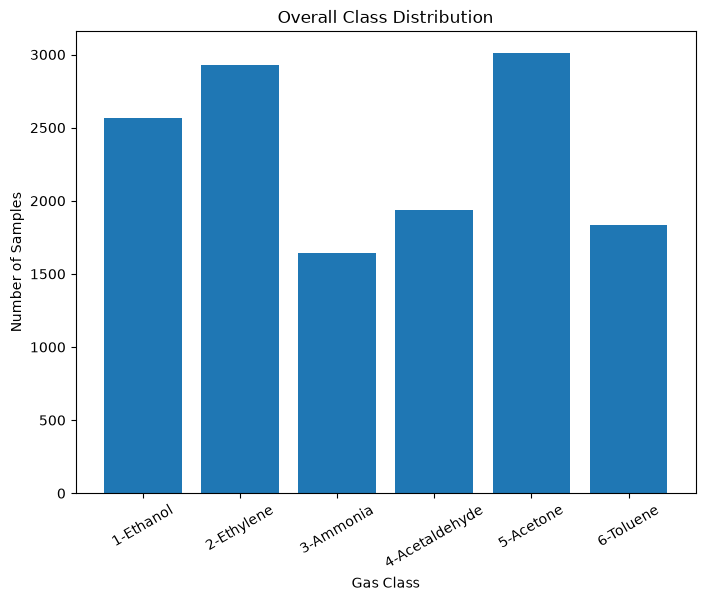

In [12]:
plt.figure(figsize=(8, 6))
plt.bar(class_counts.index, class_counts.values)
plt.title("Overall Class Distribution")
plt.xlabel("Gas Class")
plt.ylabel("Number of Samples")
plt.xticks(class_counts.index, [class_names[i] for i in class_counts.index], rotation=30)
plt.show()

### Class Distribution

The six gas classes are not perfectly balanced, and their frequencies vary across batches.

## 4. Preprocessing

### Feature Scale Analysis

The 128 features have substantially different scales, so standardization is required before training Logistic Regression with Gradient Descent.

Feature standard deviations range from approximately 0.53 to 69,842.

### Train/Test Split & Standardization

Two evaluation settings are used:

- **Random split:** baseline evaluation.
- **Temporal split:** training on earlier batches and testing on a later batch.

Standardization is fitted on the training data only to prevent data leakage.

In [13]:
np.random.seed(100)
indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

batch_train = batch_id[train_indices]
batch_test = batch_id[test_indices]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (11128, 128)
X_test: (2782, 128)
y_train: (11128,)
y_test: (2782,)


In [14]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) /std

print("Train mean:", X_train_scaled.mean())
print("Train std:", X_train_scaled.std())

Train mean: -1.5962947873834025e-17
Train std: 1.0


## 5. Logistic Regression from Scratch

In this section, Logistic Regression is implemented from scratch using NumPy.

The implementation starts with binary classification and will later be extended to the six-class gas classification problem using the One-vs-Rest strategy.

In [15]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = 0
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def log_loss(self, y, y_pred):
        epsilon = 1e-15

        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        loss = -np.mean(
            y * np.log(y_pred) +
            (1 - y) * np.log(1 - y_pred)
        )

        return loss

    def fit(self, X, y):

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        for i in range(self.n_iterations):

            z = X @ self.weights + self.bias

            y_pred = self.sigmoid(z)

            loss = self.log_loss(y, y_pred)
            self.loss_history.append(loss)

            error = y_pred - y

            dw = (X.T @ error) / n_samples
            db = error.mean()

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_proba(self, X):

        z = X @ self.weights + self.bias

        return self.sigmoid(z)

    def predict(self, X, threshold=0.5):

        probabilities = self.predict_proba(X)

        return (probabilities >= threshold).astype(int)

## 6. Binary Classification

A binary Logistic Regression model is first trained on Ethanol vs. Ethylene as a baseline before extending the approach to all six classes.

In [16]:
binary_mask = (y_train == 1) | (y_train == 2)

X_binary = X_train_scaled[binary_mask]
y_binary = y_train[binary_mask]

y_binary = (y_binary == 2).astype(int)

print("X_binary shape:", X_binary.shape)
print("y_binary shape:", y_binary.shape)
print("Classes:", np.unique(y_binary))

X_binary shape: (4350, 128)
y_binary shape: (4350,)
Classes: [0 1]


In [17]:
model = LogisticRegressionScratch(learning_rate=0.01, n_iterations=1000)
model.fit(X_binary, y_binary)
print("Final Loss:", model.loss_history[-1])

Final Loss: 0.06721821974644511


In [18]:
y_train_pred = model.predict(X_binary)

print("Predicted classes:", np.unique(y_train_pred))
print("Number of predictions:", len(y_train_pred))

Predicted classes: [0 1]
Number of predictions: 4350


In [19]:
train_accuracy = np.mean(y_train_pred == y_binary)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9917241379310345


In [20]:
binary_test_mask = (y_test == 1) | (y_test == 2)

X_binary_test = X_test_scaled[binary_test_mask]
y_binary_test =y_test[binary_test_mask]

y_binary_test = (y_binary_test == 2).astype(int)
y_test_pred = model.predict(X_binary_test)

test_accuracy =np.mean(y_test_pred == y_binary_test)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.992988606485539


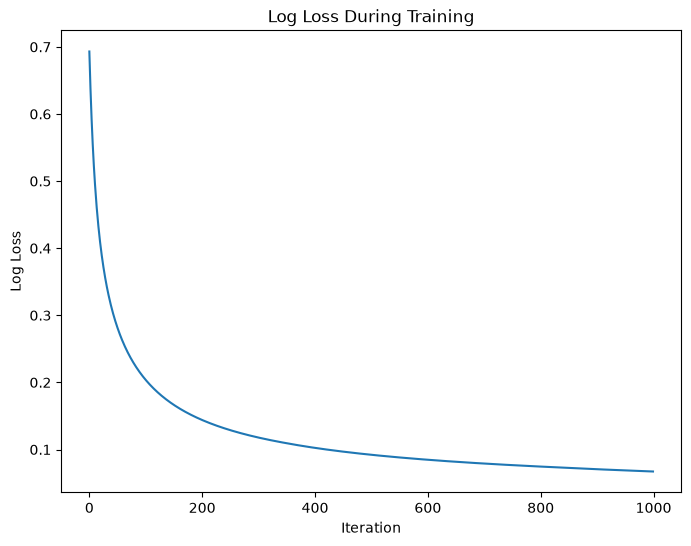

In [21]:
plt.figure(figsize=(8, 6))

plt.plot(model.loss_history)
plt.title("Log Loss During Training")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.show()

In [22]:
y_test_proba = model.predict_proba(X_binary_test)

test_loss = model.log_loss(y_binary_test, y_test_proba)
print("Test Log Loss:", test_loss)

Test Log Loss: 0.055578114862594445


## 7. Multiclass Classification with One-vs-Rest

The binary Logistic Regression model is extended to six classes using One-vs-Rest (OvR), training one binary classifier per class and selecting the class with the highest predicted probability.

In [23]:
class OneVsRestLogisticRegression:
    
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.classes = None
        self.models = [] 

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.models = []

        for current_class in self.classes:
            y_binary = (y == current_class).astype(int)

            model = LogisticRegressionScratch(learning_rate = self.learning_rate,
                n_iterations = self.n_iterations)
            
            model.fit(X, y_binary)
            self.models.append(model)

    def predict_proba(self, X):
        probabilities = []

        for model in self.models:
            probability = model.predict_proba(X)
            probabilities.append(probability)

        return np.array(probabilities).T

    def predict(self, X):

        probabilities = self.predict_proba(X)
        class_indices = np.argmax(probabilities, axis=1)

        return self.classes[class_indices]

In [24]:
ovr_baseline = OneVsRestLogisticRegression(learning_rate=0.01, n_iterations=1000)

ovr_baseline.fit(X_train_scaled, y_train)

print("Number of models:", len(ovr_baseline.models))
print("Classes:", ovr_baseline.classes)

Number of models: 6
Classes: [1 2 3 4 5 6]


In [25]:
test_proba = ovr_baseline.predict_proba(X_test_scaled)

print("Probability shape: ", test_proba.shape)
print("First sample probabilities: ", test_proba[0])
print("True class: ", y_test[0])

Probability shape:  (2782, 6)
First sample probabilities:  [0.08763884 0.07607042 0.18787031 0.28645744 0.32415041 0.38559983]
True class:  6


In [26]:
y_pred_baseline = ovr_baseline.predict(X_test_scaled)
accuracy = np.mean(y_test == y_pred_baseline)
print("Test Accuracy: ", accuracy)

Test Accuracy:  0.8497483824586628


In [27]:
classes = np.unique(y_test)

confusion_matrix = np.zeros(
    (len(classes), len(classes)),
    dtype=int
)

for true_class, predicted_class in zip(y_test, y_pred_baseline):
    true_index = np.where(classes == true_class)[0][0]
    predicted_index = np.where(classes == predicted_class)[0][0]

    confusion_matrix[true_index, predicted_index] += 1

print(confusion_matrix)

[[516   0   1   0  23  18]
 [  1 548   1   0   5  28]
 [  0   2 317   0   3  26]
 [ 74   4   0 159  45  93]
 [  5   0   1   1 520  37]
 [  2   0   0   0  48 304]]


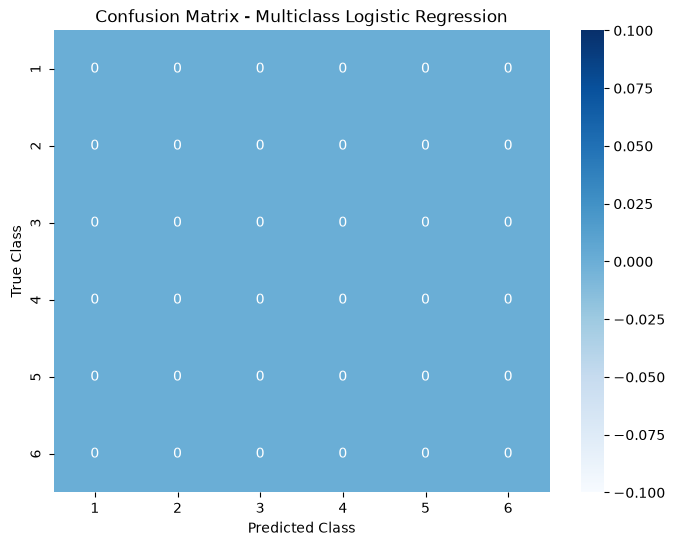

In [28]:
classes = np.unique(y_test)

confusion_matrix = np.zeros(
    (len(classes), len(classes)),
    dtype=int
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - Multiclass Logistic Regression")
plt.show()

## 8. Hyperparameter Experiment

The learning rate and number of iterations were varied to examine their effect on model convergence and test performance.

In [29]:
experiments = [
    (0.01, 1000),
    (0.1, 2000),
    (0.1, 3000)
]

experiment_results = []

for learning_rate, n_iterations in experiments:

    model = OneVsRestLogisticRegression(
        learning_rate=learning_rate,
        n_iterations=n_iterations
    )

    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)
    accuracy = np.mean(predictions == y_test)

    experiment_results.append({
        "Learning Rate": learning_rate,
        "Iterations": n_iterations,
        "Test Accuracy": accuracy
    })

experiment_results_df = pd.DataFrame(experiment_results)

print(experiment_results_df)

   Learning Rate  Iterations  Test Accuracy
0           0.01        1000       0.849748
1           0.10        2000       0.951114
2           0.10        3000       0.957225


In [30]:
ovr_model = OneVsRestLogisticRegression(
    learning_rate=0.1,
    n_iterations=3000
)

ovr_model.fit(X_train_scaled, y_train)

y_pred_tuned = ovr_model.predict(X_test_scaled)

In [31]:
ovr_model_confusion_matrix = np.zeros(
    (len(classes), len(classes)),
    dtype=int
)

for true_class, predicted_class in zip(
    y_test,
    y_pred_tuned
):

    true_index = np.where(classes == true_class)[0][0]
    predicted_index = np.where(classes == predicted_class)[0][0]

    ovr_model_confusion_matrix[
        true_index,
        predicted_index
    ] += 1

print(ovr_model_confusion_matrix)

[[542   0   0  14   2   0]
 [  1 577   1   0   3   1]
 [  0   7 333   3   3   2]
 [  7   2   0 331   1  34]
 [  2   0   1   5 551   5]
 [  1   0   0  22   2 329]]


## 9. Error Analysis

Using the tuned model's predictions on the random test split, we look at which classes are most often confused with each other, and whether errors are concentrated in specific batches.

In [32]:
for i, true_class in enumerate(classes):

    errors = ovr_model_confusion_matrix[i].copy()
    errors[i] = 0

    most_confused_index = np.argmax(errors)
    most_confused_class = classes[most_confused_index]
    error_count = errors[most_confused_index]

    print(
        f"Class {true_class} is most often confused with "
        f"Class {most_confused_class}: {error_count} samples"
    )

Class 1 is most often confused with Class 4: 14 samples
Class 2 is most often confused with Class 5: 3 samples
Class 3 is most often confused with Class 2: 7 samples
Class 4 is most often confused with Class 6: 34 samples
Class 5 is most often confused with Class 4: 5 samples
Class 6 is most often confused with Class 4: 22 samples


In [33]:
pair_errors = []

for i in range(len(classes)):
    for j in range(i + 1, len(classes)):

        total = ovr_model_confusion_matrix[i, j] + ovr_model_confusion_matrix[j, i]

        pair_errors.append(
            (
                total,
                classes[i],
                classes[j],
                ovr_model_confusion_matrix[i, j],
                ovr_model_confusion_matrix[j, i]
            )
        )

pair_errors.sort(reverse=True)

for total, class_1, class_2, error_1, error_2 in pair_errors:
    print(
        f"Class {class_1} ↔ Class {class_2}: "
        f"{total} errors "
        f"({class_1} → {class_2}: {error_1}, "
        f"{class_2} → {class_1}: {error_2})"
    )

Class 4 ↔ Class 6: 56 errors (4 → 6: 34, 6 → 4: 22)
Class 1 ↔ Class 4: 21 errors (1 → 4: 14, 4 → 1: 7)
Class 2 ↔ Class 3: 8 errors (2 → 3: 1, 3 → 2: 7)
Class 5 ↔ Class 6: 7 errors (5 → 6: 5, 6 → 5: 2)
Class 4 ↔ Class 5: 6 errors (4 → 5: 1, 5 → 4: 5)
Class 3 ↔ Class 5: 4 errors (3 → 5: 3, 5 → 3: 1)
Class 1 ↔ Class 5: 4 errors (1 → 5: 2, 5 → 1: 2)
Class 3 ↔ Class 4: 3 errors (3 → 4: 3, 4 → 3: 0)
Class 2 ↔ Class 5: 3 errors (2 → 5: 3, 5 → 2: 0)
Class 3 ↔ Class 6: 2 errors (3 → 6: 2, 6 → 3: 0)
Class 2 ↔ Class 4: 2 errors (2 → 4: 0, 4 → 2: 2)
Class 2 ↔ Class 6: 1 errors (2 → 6: 1, 6 → 2: 0)
Class 1 ↔ Class 6: 1 errors (1 → 6: 0, 6 → 1: 1)
Class 1 ↔ Class 2: 1 errors (1 → 2: 0, 2 → 1: 1)
Class 1 ↔ Class 3: 0 errors (1 → 3: 0, 3 → 1: 0)


In [34]:
errors_mask = y_pred_tuned != y_test
error_df = pd.DataFrame({
    "true_class": y_test[errors_mask],
    "predicted_class": y_pred_tuned[errors_mask],
    "batch": batch_test[errors_mask]
})
error_df.head()

,true_class,predicted_class,batch
0,5,4,9
1,4,1,10
2,6,4,10
3,4,1,10
4,6,4,10


In [35]:
batch_results = []

for batch in np.unique(batch_test):
    
    mask = batch_test == batch
    
    total_samples = mask.sum()
    errors = np.sum(y_pred_tuned[mask] != y_test[mask])
    error_rate = errors / total_samples

    batch_results.append([batch, total_samples, errors, error_rate])

batch_results_df = pd.DataFrame(
    batch_results,
    columns=["Batch", "Samples", "Errors", "Error Rate"]
)
print(batch_results_df)


   Batch  Samples  Errors  Error Rate
0      1       85      16    0.188235
1      2      236       9    0.038136
2      3      344       5    0.014535
3      4       32       3    0.093750
4      5       36       1    0.027778
5      6      458       2    0.004367
6      7      721       2    0.002774
7      8       51       3    0.058824
8      9       98       3    0.030612
9     10      721      75    0.104022


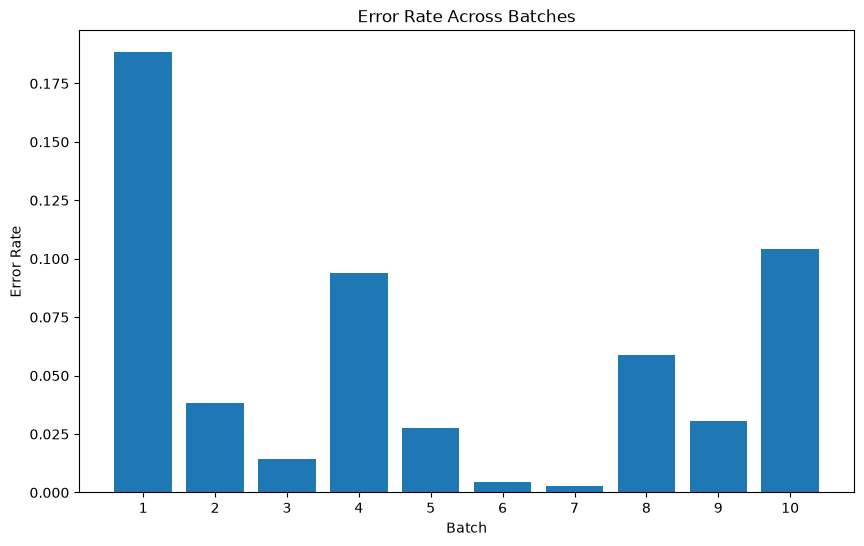

In [36]:
plt.figure(figsize=(10, 6))

plt.bar(
    batch_results_df["Batch"],
    batch_results_df["Error Rate"]
)
plt.title("Error Rate Across Batches")
plt.xlabel("Batch")
plt.ylabel("Error Rate")
plt.xticks(batch_results_df["Batch"])

plt.show()

## 10. Temporal Evaluation

Batch 1–9 are used for training and Batch 10 is held out as a later test period.

This evaluates how well the model generalizes to data collected at a later time.

In [37]:
temporal_train_mask = batch_id <= 9
temporal_test_mask = batch_id == 10

X_temporal_train = X[temporal_train_mask]
y_temporal_train = y[temporal_train_mask]

X_temporal_test = X[temporal_test_mask]
y_temporal_test = y[temporal_test_mask]

print("Train shape:", X_temporal_train.shape)
print("Test shape:", X_temporal_test.shape)
print("Train classes:", np.unique(y_temporal_train))
print("Test classes:", np.unique(y_temporal_test))

Train shape: (10310, 128)
Test shape: (3600, 128)
Train classes: [1 2 3 4 5 6]
Test classes: [1 2 3 4 5 6]


In [38]:
temporal_mean = X_temporal_train.mean(axis=0)
temporal_std = X_temporal_train.std(axis=0)

X_temporal_train_scaled = (X_temporal_train - temporal_mean) / temporal_std
X_temporal_test_scaled = (X_temporal_test - temporal_mean) / temporal_std

print("Train mean:", X_temporal_train_scaled.mean())
print("Train std:", X_temporal_train_scaled.std())

Train mean: 3.6939952120990657e-16
Train std: 1.0


In [39]:
temporal_model = OneVsRestLogisticRegression(
    learning_rate=0.1,
    n_iterations=3000
)

temporal_model.fit(
    X_temporal_train_scaled,
    y_temporal_train
)

In [40]:
temporal_y_pred = temporal_model.predict(X_temporal_test_scaled)

temporal_accuracy = np.mean(temporal_y_pred == y_temporal_test)

print("Temporal Test Accuracy:", temporal_accuracy)

Temporal Test Accuracy: 0.7444444444444445


In [41]:
temporal_classes = np.unique(y_temporal_test)

temporal_confusion_matrix = np.zeros(
    (len(temporal_classes), len(temporal_classes)),
    dtype=int
)

for true_class, predicted_class in zip(
    y_temporal_test,
    temporal_y_pred
):

    true_index = np.where(temporal_classes == true_class)[0][0]
    predicted_index = np.where(temporal_classes == predicted_class)[0][0]

    temporal_confusion_matrix[
        true_index,
        predicted_index
    ] += 1

print(temporal_confusion_matrix)

[[537   0   0   0  17  46]
 [  0 531   1   0  68   0]
 [ 11  81 447   8  46   7]
 [202   0   0 245   6 147]
 [  0   0  17   1 475 107]
 [ 81   0   0  73   1 445]]


In [42]:
temporal_precision = []
temporal_recall = []
temporal_f1 = []

for i in range(len(classes)):

    true_positive = temporal_confusion_matrix[i, i]
    false_positive = (
        temporal_confusion_matrix[:, i].sum()
        - true_positive
    )
    false_negative = (
        temporal_confusion_matrix[i, :].sum()
        - true_positive
    )

    p = true_positive / (true_positive + false_positive)
    r = true_positive / (true_positive + false_negative)

    f = 2 * (p * r) / (p + r)

    temporal_precision.append(p)
    temporal_recall.append(r)
    temporal_f1.append(f)

print("Temporal Precision:", temporal_precision)
print("Temporal Recall:", temporal_recall)
print("Temporal F1:", temporal_f1)

Temporal Precision: [np.float64(0.6462093862815884), np.float64(0.8676470588235294), np.float64(0.9612903225806452), np.float64(0.7492354740061162), np.float64(0.7748776508972267), np.float64(0.5917553191489362)]
Temporal Recall: [np.float64(0.895), np.float64(0.885), np.float64(0.745), np.float64(0.4083333333333333), np.float64(0.7916666666666666), np.float64(0.7416666666666667)]
Temporal F1: [np.float64(0.7505241090146751), np.float64(0.8762376237623763), np.float64(0.83943661971831), np.float64(0.528586839266451), np.float64(0.7831821929101401), np.float64(0.658284023668639)]


In [43]:
temporal_macro_precision = np.mean(temporal_precision)
temporal_macro_recall = np.mean(temporal_recall)
temporal_macro_f1 = np.mean(temporal_f1)

temporal_class_support = temporal_confusion_matrix.sum(axis=1)

temporal_weighted_precision = np.average(
    temporal_precision,
    weights=temporal_class_support
)

temporal_weighted_recall = np.average(
    temporal_recall,
    weights=temporal_class_support
)

temporal_weighted_f1 = np.average(
    temporal_f1,
    weights=temporal_class_support
)

print("Temporal Macro Precision:", temporal_macro_precision)
print("Temporal Macro Recall:", temporal_macro_recall)
print("Temporal Macro F1:", temporal_macro_f1)
print("Temporal Weighted Precision:", temporal_weighted_precision)
print("Temporal Weighted Recall:", temporal_weighted_recall)
print("Temporal Weighted F1:", temporal_weighted_f1)

Temporal Macro Precision: 0.7651692019563404
Temporal Macro Recall: 0.7444444444444445
Temporal Macro F1: 0.739375234723432
Temporal Weighted Precision: 0.7651692019563404
Temporal Weighted Recall: 0.7444444444444445
Temporal Weighted F1: 0.739375234723432


## 11. Distribution Shift

We compare feature distributions between the training batches (1–9) and the held-out Batch 10 to investigate potential distribution shift over time.

In [44]:
train_feature_mean = X_temporal_train.mean(axis=0)
test_feature_mean = X_temporal_test.mean(axis=0)

mean_shift = np.abs(
    test_feature_mean - train_feature_mean
)

print("Mean absolute shift:", mean_shift.mean())
print("Maximum feature shift:", mean_shift.max())

Mean absolute shift: 443.86989391330826
Maximum feature shift: 7969.7653848290065


In [45]:
standardized_shift = np.abs(
    (X_temporal_test.mean(axis=0) - X_temporal_train.mean(axis=0))
    / X_temporal_train.std(axis=0)
)

print("Mean standardized shift:", standardized_shift.mean())
print("Maximum standardized shift:", standardized_shift.max())

Mean standardized shift: 0.25985320220662056
Maximum standardized shift: 1.4626962472472


In [46]:
top_indices = np.argsort(standardized_shift)[-10:][::-1]

for index in top_indices:
    print(
        f"Feature {index + 1}: "
        f"{standardized_shift[index]:.3f}"
    )

Feature 72: 1.463
Feature 80: 1.270
Feature 98: 0.949
Feature 106: 0.922
Feature 16: 0.789
Feature 108: 0.558
Feature 107: 0.499
Feature 77: 0.490
Feature 38: 0.460
Feature 100: 0.455


## 12. Scikit-learn Benchmark

Scikit-learn's Logistic Regression is used as an external benchmark on the same random and temporal splits.

In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
sklearn_model = LogisticRegression(
    max_iter=1000
)

sklearn_model.fit(
    X_train_scaled,
    y_train
)

sklearn_y_pred = sklearn_model.predict(
    X_test_scaled
)

sklearn_accuracy = np.mean(
    sklearn_y_pred == y_test
)

print("Scikit-learn Accuracy:", sklearn_accuracy)

Scikit-learn Accuracy: 0.99137311286844


In [49]:
sklearn_confusion_matrix = np.zeros(
    (len(classes), len(classes)),
    dtype=int
)

for true_class, predicted_class in zip(
    y_test,
    sklearn_y_pred
):

    true_index = np.where(classes == true_class)[0][0]
    predicted_index = np.where(classes == predicted_class)[0][0]

    sklearn_confusion_matrix[
        true_index,
        predicted_index
    ] += 1

print(sklearn_confusion_matrix)

[[555   0   0   0   3   0]
 [  1 579   2   0   1   0]
 [  0   1 343   0   4   0]
 [  0   0   0 375   0   0]
 [  0   3   1   2 556   2]
 [  1   0   0   2   1 350]]


In [50]:
sklearn_temporal_model = LogisticRegression(
    max_iter=3000
)

sklearn_temporal_model.fit(
    X_temporal_train_scaled,
    y_temporal_train
)

sklearn_temporal_y_pred = sklearn_temporal_model.predict(
    X_temporal_test_scaled
)

sklearn_temporal_accuracy = np.mean(
    sklearn_temporal_y_pred == y_temporal_test
)

print(
    "Scikit-learn Temporal Accuracy:",
    sklearn_temporal_accuracy
)

Scikit-learn Temporal Accuracy: 0.7147222222222223


## 13. Final Results

The final results compare the model under random and temporal evaluation settings.

The temporal evaluation shows how performance changes when the model is tested on a later batch, while the distribution-shift analysis provides additional evidence that feature distributions change over time.

**Limitations & possible next steps:** periodic recalibration, drift-robust features, or incremental retraining on new batches could be explored to improve robustness to future distribution changes.

In [51]:
random_recall = []
temporal_recall = []

for i in range(len(classes)):

    random_tp = ovr_model_confusion_matrix[i, i]
    random_total = ovr_model_confusion_matrix[i].sum()

    random_recall.append(random_tp / random_total)

    temporal_tp = temporal_confusion_matrix[i, i]
    temporal_total = temporal_confusion_matrix[i].sum()

    temporal_recall.append(temporal_tp / temporal_total)


recall_comparison = pd.DataFrame({
    "Class": classes,
    "Random Recall": random_recall,
    "Temporal Recall": temporal_recall
})

recall_comparison["Recall Drop"] = (
    recall_comparison["Random Recall"]
    - recall_comparison["Temporal Recall"]
)

print(recall_comparison)

   Class  Random Recall  Temporal Recall  Recall Drop
0      1       0.971326         0.895000     0.076326
1      2       0.989708         0.885000     0.104708
2      3       0.956897         0.745000     0.211897
3      4       0.882667         0.408333     0.474333
4      5       0.976950         0.791667     0.185284
5      6       0.929379         0.741667     0.187712


### Final Takeaways

The scratch Logistic Regression model achieves 95.72% accuracy under the random split and 74.44% under the temporal split.

The performance drop on the later batch indicates that random-split performance does not fully represent the model's ability to generalize to future data. The recall analysis shows that the impact is not uniform across classes, with Acetaldehyde showing the largest drop.

The distribution-shift analysis provides additional evidence that feature distributions change between earlier and later batches, which may be associated with sensor drift and changing measurement conditions.